In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.loader import DataLoader
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
from tqdm.notebook import tqdm
import time

from halide_gnn_cost_model.data import PipelineDataset
from halide_gnn_cost_model.model import PipeGCN, PipeGAT, PipelineModel

In [2]:
PIPELINES_DIR = Path("/lscratch/fzhou48/pipelines-16k-data")
GCN_MODELS_DIR = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/gcn")
GAT_MODELS_DIR = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models/gat")
# Create models directory if it doesn't exist
GCN_MODELS_DIR.mkdir(parents=True, exist_ok=True)
GAT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
summary_writer = SummaryWriter(log_dir="resources/runs/" + time.strftime("%Y%m%d-%H%M%S"))

In [4]:
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
elif USE_GPU and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
# Load dataset
dataset = PipelineDataset(PIPELINES_DIR)
data = dataset[0]  # Get the first pipeline graph
data.metadata()

1lines [00:00, 5949.37lines/s]
1lines [00:00, 10565.00lines/s]


(['function', 'ast_node', 'loop_level'],
 [('function', 'called_by', 'function'),
  ('function', 'call', 'function'),
  ('ast_node', 'child_of', 'ast_node'),
  ('ast_node', 'parent_of', 'ast_node'),
  ('ast_node', 'is_expr_of', 'function'),
  ('function', 'contains_expr', 'ast_node'),
  ('loop_level', 'child_of', 'loop_level'),
  ('loop_level', 'parent_of', 'loop_level'),
  ('function', 'schedule_at', 'loop_level'),
  ('loop_level', 'schedule', 'function')])

In [6]:
# Train/test split
num_train = int(0.95 * len(dataset))
train_dataset, test_dataset = random_split(dataset, [num_train, len(dataset) - num_train])
len(train_dataset), len(test_dataset)

(15605, 822)

# GCN

In [7]:
DIM_EMBEDDING = 64
gcn = PipeGCN(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

In [8]:
model = PipelineModel(gcn, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model = model.to(device)
model

PipelineModel(
  (function_gnn): GraphModule(
    (convs): ModuleList(
      (0-3): 4 x ModuleDict(
        (function__called_by__function): SAGEConv(-1, 64, aggr=add)
        (function__call__function): SAGEConv(-1, 64, aggr=add)
        (ast_node__child_of__ast_node): SAGEConv(-1, 64, aggr=add)
        (ast_node__parent_of__ast_node): SAGEConv(-1, 64, aggr=add)
        (ast_node__is_expr_of__function): SAGEConv(-1, 64, aggr=add)
        (function__contains_expr__ast_node): SAGEConv(-1, 64, aggr=add)
        (loop_level__child_of__loop_level): SAGEConv(-1, 64, aggr=add)
        (loop_level__parent_of__loop_level): SAGEConv(-1, 64, aggr=add)
        (function__schedule_at__loop_level): SAGEConv(-1, 64, aggr=add)
        (loop_level__schedule__function): SAGEConv(-1, 64, aggr=add)
      )
    )
  )
  (ast_embedding): Embedding(14, 32)
  (sched_embedding): Embedding(8, 32)
  (pipeline_lin): Linear(in_features=64, out_features=5, bias=True)
)

In [9]:
data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4)
data_loader

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 3, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
# Save model every n epochs
SAVE_EVERY = 20

# Train loop (example)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

for epoch in tqdm(range(100)):
    model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(data_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        pred = model(batch, batch["loop_level"].ptr)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), torch.log(batch.y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        summary_writer.add_scalar("Loss/train", loss.item(), epoch * len(data_loader) + batch_idx)
    # Print average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # Save model
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save(model.state_dict(), GCN_MODELS_DIR / f"pipeline_model_epoch_{epoch+1}.pt")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1, Loss: 21.4473
Epoch 2, Loss: 2.1188
Epoch 3, Loss: 1.9942
Epoch 4, Loss: 1.8843
Epoch 5, Loss: 1.7663
Epoch 6, Loss: 1.6614
Epoch 7, Loss: 1.5805
Epoch 8, Loss: 1.5183
Epoch 9, Loss: 1.4580
Epoch 10, Loss: 1.4083
Epoch 11, Loss: 1.3442
Epoch 12, Loss: 1.3171
Epoch 13, Loss: 1.2995
Epoch 14, Loss: 1.2584
Epoch 15, Loss: 1.2070
Epoch 16, Loss: 1.1857
Epoch 17, Loss: 1.1858
Epoch 18, Loss: 1.1429
Epoch 19, Loss: 1.1345
Epoch 20, Loss: 1.1037
Epoch 21, Loss: 1.1020
Epoch 22, Loss: 1.0861
Epoch 23, Loss: 1.0796
Epoch 24, Loss: 1.0757
Epoch 25, Loss: 1.0621
Epoch 26, Loss: 1.0431
Epoch 27, Loss: 1.0351
Epoch 28, Loss: 1.0465
Epoch 29, Loss: 1.0180
Epoch 30, Loss: 1.0065
Epoch 31, Loss: 0.9788
Epoch 32, Loss: 0.9798
Epoch 33, Loss: 0.9715
Epoch 34, Loss: 0.9742
Epoch 35, Loss: 0.9444
Epoch 36, Loss: 0.9471
Epoch 37, Loss: 0.9370
Epoch 38, Loss: 0.9408
Epoch 39, Loss: 0.9357
Epoch 40, Loss: 0.9395
Epoch 41, Loss: 0.9183
Epoch 42, Loss: 0.9173
Epoch 43, Loss: 0.9092
Epoch 44, Loss: 0.9

## Eval

In [11]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred = model(batch, batch["loop_level"].ptr)
            error_rates = torch.abs(pred.reshape(-1) - batch.y) / batch.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [12]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 360.68%


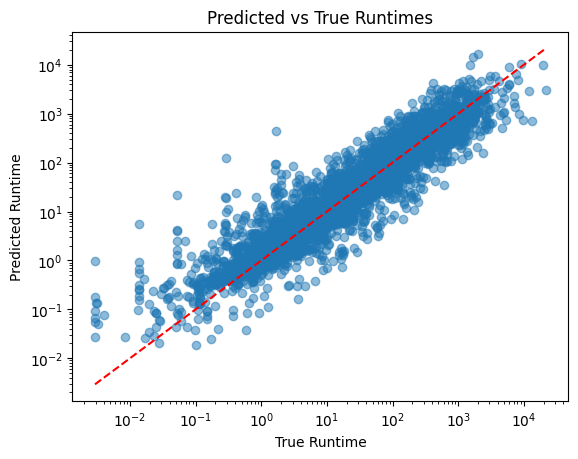

In [13]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = torch.exp(model(batch, batch["loop_level"].ptr))
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(batch.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [14]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    sample_data = sample_data.to(device)
    pred_runtime = torch.exp(model(sample_data))
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([[  0.9221,   3.4741,  16.0788,  71.4594, 335.2404]], device='cuda:0'), True runtime: tensor([  0.8992,   3.6038,  15.7628,  67.0819, 602.7916], device='cuda:0')


# GAT

In [15]:
DIM_EMBEDDING = 64
gcn = PipeGAT(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

In [16]:
model = PipelineModel(gcn, DIM_EMBEDDING, 5, len(dataset.ast_vocab), len(dataset.sched_vocab))
model = model.to(device)
model

PipelineModel(
  (function_gnn): GraphModule(
    (convs): ModuleList(
      (0-3): 4 x ModuleDict(
        (function__called_by__function): GATConv(-1, 64, heads=1)
        (function__call__function): GATConv(-1, 64, heads=1)
        (ast_node__child_of__ast_node): GATConv(-1, 64, heads=1)
        (ast_node__parent_of__ast_node): GATConv(-1, 64, heads=1)
        (ast_node__is_expr_of__function): GATConv(-1, 64, heads=1)
        (function__contains_expr__ast_node): GATConv(-1, 64, heads=1)
        (loop_level__child_of__loop_level): GATConv(-1, 64, heads=1)
        (loop_level__parent_of__loop_level): GATConv(-1, 64, heads=1)
        (function__schedule_at__loop_level): GATConv(-1, 64, heads=1)
        (loop_level__schedule__function): GATConv(-1, 64, heads=1)
      )
    )
  )
  (ast_embedding): Embedding(14, 32)
  (sched_embedding): Embedding(8, 32)
  (pipeline_lin): Linear(in_features=64, out_features=5, bias=True)
)

In [17]:
data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4)
data_loader

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 3, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [18]:
# Save model every n epochs
SAVE_EVERY = 20

# Train loop (example)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

for epoch in tqdm(range(100)):
    model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(data_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        pred = model(batch, batch["loop_level"].ptr)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), torch.log(batch.y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        summary_writer.add_scalar("Loss/train", loss.item(), epoch * len(data_loader) + batch_idx)
    # Print average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # Save model
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save(model.state_dict(), GAT_MODELS_DIR / f"pipeline_model_epoch_{epoch+1}.pt")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1, Loss: 8.6246
Epoch 2, Loss: 2.1360
Epoch 3, Loss: 1.9858
Epoch 4, Loss: 1.8977
Epoch 5, Loss: 1.8141
Epoch 6, Loss: 1.7056
Epoch 7, Loss: 1.6095
Epoch 8, Loss: 1.5333
Epoch 9, Loss: 1.4777
Epoch 10, Loss: 1.4288
Epoch 11, Loss: 1.4009
Epoch 12, Loss: 1.3747
Epoch 13, Loss: 1.3369
Epoch 14, Loss: 1.3205
Epoch 15, Loss: 1.2980
Epoch 16, Loss: 1.2910
Epoch 17, Loss: 1.2652
Epoch 18, Loss: 1.2526
Epoch 19, Loss: 1.2438
Epoch 20, Loss: 1.2274
Epoch 21, Loss: 1.2219
Epoch 22, Loss: 1.2135
Epoch 23, Loss: 1.2122
Epoch 24, Loss: 1.1920
Epoch 25, Loss: 1.1828
Epoch 26, Loss: 1.1855
Epoch 27, Loss: 1.1791
Epoch 28, Loss: 1.1754
Epoch 29, Loss: 1.1669
Epoch 30, Loss: 1.1699
Epoch 31, Loss: 1.1417
Epoch 32, Loss: 1.1513
Epoch 33, Loss: 1.1428
Epoch 34, Loss: 1.1346
Epoch 35, Loss: 1.1335
Epoch 36, Loss: 1.1198
Epoch 37, Loss: 1.1199
Epoch 38, Loss: 1.1096
Epoch 39, Loss: 1.1125
Epoch 40, Loss: 1.1060
Epoch 41, Loss: 1.0920
Epoch 42, Loss: 1.0887
Epoch 43, Loss: 1.0827
Epoch 44, Loss: 1.08

## Eval

In [19]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred = model(batch, batch["loop_level"].ptr)
            error_rates = torch.abs(pred.reshape(-1) - batch.y) / batch.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [20]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 305.84%


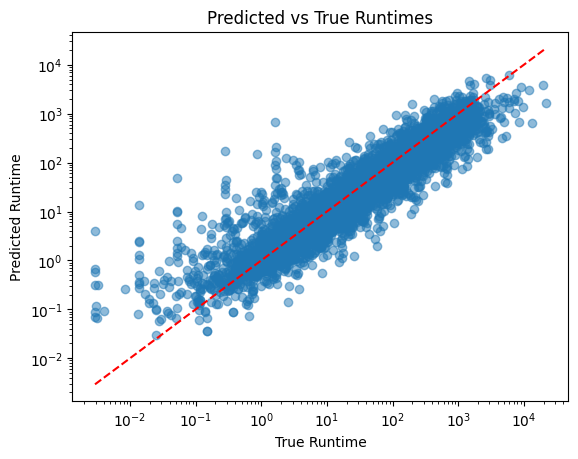

In [21]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = torch.exp(model(batch, batch["loop_level"].ptr))
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(batch.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [22]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    sample_data = sample_data.to(device)
    pred_runtime = torch.exp(model(sample_data))
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([[  0.7912,   2.8034,  13.5624,  51.1350, 253.9213]], device='cuda:0'), True runtime: tensor([  0.8992,   3.6038,  15.7628,  67.0819, 602.7916], device='cuda:0')
